# Data exploring cases Constitutional Court

## Setting up

In [2]:
# import relevant packages
import os
import pandas as pd
import numpy as np
import re
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
# show all outputs of cell, not merely of last line (i.e. default of Jupyter Notebook)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [11]:
# Set data_location and filename of data
data_location = '../data'
filename_input = 'CC_2025-2025.pkl'
data_location + "/" + filename_input

'../data/CC_2025-2025.pkl'

In [12]:
os.getcwd()

'/workspaces/keywords_decisions_CoS/notebooks'

In [13]:
# # Run file with various functions, located 'code' folder (so i.c. 1 position up in branch)
# %run -i ../functions_misc_CC.ipynb

## Reading in data

First, we read in the data file and explore its shape.

In [14]:
# Read in data file
data = pd.read_pickle(data_location + "/" + filename_input)
data

,case number,role number,date,type procedure,controlled norm,outcome,keywords,url
0,61/2025,[8423],03/04/2025,Beroep tot vernietiging,Wetten en procedures inzake gedeeltelijke verb...,Verwerping van het beroep,"[Voorafgaande rechtspleging, Beroep tot vernie...",www.const-court.be/public/n/2025/2025-061n.pdf
1,60/2025,[8286],03/04/2025,Prejudiciële vraag,"Wetboek van economisch recht (artikel I.1, eer...",Onontvankelijkheid van de prejudiciële vraag,"[Economisch recht, Insolventie van onderneming...",www.const-court.be/public/n/2025/2025-060n.pdf
2,59/2025,[8285],03/04/2025,Beroep tot vernietiging,Ordonnantie van het Brusselse Hoofdstedelijke ...,Vernietiging,"[Fiscaal recht, Registratierechten, Brusselse ...",www.const-court.be/public/n/2025/2025-059n.pdf
3,58/2025,[8266],03/04/2025,Beroep tot vernietiging,Programmawet van 22 december 2023 (artikel 114),Verwerping van het beroep,"[Sociaal recht, Sociale zekerheid, Ziekte- en ...",www.const-court.be/public/n/2025/2025-058n.pdf
4,57/2025,"[8224, 8223]",03/04/2025,Prejudiciële vragen,Wet van 17 april 1878 « houdende de voorafgaan...,Geen schending (artikel 26 van de wet van 17 a...,"[Sociale zekerheid, Ziekte- en invaliditeitsve...",www.const-court.be/public/n/2025/2025-057n.pdf
...,...,...,...,...,...,...,...,...
56,5/2025,"[8157, 8156]",16/01/2025,Beroepen tot vernietiging,Decreet van het Vlaamse Gewest van 23 juni 202...,"- Vernietiging (artikel 5, eerste lid, 1°, van...","[Bestuursrecht, Grond- en pandenbeleid, Wonen ...",www.const-court.be/public/n/2025/2025-005n.pdf
57,4/2025,[8154],16/01/2025,Prejudiciële vraag,Wetboek van de inkomstenbelastingen 1992 (arti...,"Geen schending (artikel 269, § 2, eerste lid, ...","[Fiscaal recht, Inkomstenbelastingen, Personen...",www.const-court.be/public/n/2025/2025-004n.pdf
58,3/2025,[8148],16/01/2025,Beroep tot vernietiging,Ordonnantie van het Brusselse Hoofdstedelijke ...,- Vernietiging- Handhaving van de gevolgen van...,"[Ruimtelijke ordening, Brussels Hoofdstedelijk...",www.const-court.be/public/n/2025/2025-003n.pdf
59,2/2025,[8144],09/01/2025,Prejudiciële vraag,Brusselse Huisvestingscode (artikel 10),"Schending (artikel 10, § 3, van de Brusselse H...","[Huisvesting, Brussels Hoofdstedelijk Gewest, ...",www.const-court.be/public/n/2025/2025-002n.pdf


In [15]:
# explore data
data.shape
data.dtypes

(61, 8)

case number        object
role number        object
date               object
type procedure     object
controlled norm    object
outcome            object
keywords           object
url                object
dtype: object

## Helper functions

First, we define some functions to aid in the exploration: 
* `keywords_clean()`: function to clean keywords (stripping, lower case ...)
* `frequent()`: create nested list showing values in variable together with their count (descending)
* `plot_frequent()`: plot this frequency overview

In [16]:
#Define function to clean keywords of each case
def keywords_clean(keywords_list: list):
    keywords_list = [i.lower() for i in keywords_list if i != ""] # remove left over empty characters + return lower case  
    keywords_list = [re.sub(r"1\.|2\.|\.", "", i) for i in keywords_list ] # remove "1.", "2." and "." (with "." always escaped)   
    keywords_list = [i.replace("  ", " ").strip(" ") for i in keywords_list] # remove double spaces in keywords
    
    return keywords_list

In [17]:
def frequent(value_list: list, minimum_count = 0):
    """
    Function to sort variable values accoring to their frequency, and show them together with their count as nested list.
    'value_list' is a list of all values for a particular variable as they occur in the dataset (so including duplicates)
    
    [['fiscaal recht', 439],
     ['sociaal recht', 432],
     ['sociale zekerheid', 371],
     ['inkomstenbelastingen', 303],
     ...
     ]
    """
    # Determine amount of unique values
    unique = list(set(value_list))
    
    # Create counter item of 
    values_counter = Counter(value_list)
    
    frequent = []
    for value, count in values_counter.items():
        if count > minimum_count:
            frequent.append([value, count])

    # sort values based on how much they occur (high to low)
    frequent = sorted(frequent, key = lambda x: x[1], reverse = True)
    
    print("{0:,d} keywords out of {1:,d} unique values occur more than {2} times.\nThey represent {3:,d} of the total amount of values (i.e. {4:,d}), so {5:2.2%}.".
          format(
             len(frequent),
             len(unique),
             minimum_count,
             sum(i[1] for i in frequent), # show sum of counts for those values, i.e. sum of all included values
             len(value_list),
            sum(i[1] for i in frequent)/len(value_list)
             )
         )

    return frequent

In [32]:
def plot_frequent (frequent_item: list, title = "", filename = "", export = False):
    """
    Plot frequency of values in variable
    * frequent_item: nested list as created with `function` 
    * title: title of plot, e.g. "Frequency of keywords"
    * export: boolean to indicate whether graph should be saved; default: True
    * filename: name of file to export, e.g. "CC_most_frequent_keywords.png"
    """
    
    labels = [frequent_item[i][0] for i in range(len(frequent_item))] # extract labels from 'frequent'
    count = [frequent_item[i][1] for i in range(len(frequent_item))] # extract corresponding counts from 'frequent'

    # change width and height of figure
    f = plt.figure()
    f.set_figwidth(40)
    f.set_figheight(10)

    # plt.xticks([]) # disabling xticks by Setting xticks to an empty list  (because to clotted)
    # plt.xticks(labels = None) # hide labels 
    plt.xticks(rotation = 90) # rotate labels of values
    plt.yticks(range(0,len(labels)+1, 5))#set the tick frequency on x-axis
    plt.xlabel("values") #set the label for y axis
    plt.ylabel("count") #set the label for x-axis
    plt.title(title) #set the title of the graph

    plt.bar(labels, count)
    plt.show()
    
    if export == True:
        f.savefig('../graphs/' + filename)

## Keywords

Subsequently we extract all keywords and explore those and obtain all seperate keywords from the list that is provided for each case.

In [18]:
# extract all keywords
keywords_list = data["keywords"].tolist() # apply ".to_list()" or output is Series

# inspect results
len(keywords_list)
type(keywords_list)
keywords_list[:5]

61

list

[['Voorafgaande rechtspleging',
  'Beroep tot vernietiging',
  'Klaarblijkelijke niet-ontvankelijkheid'],
 ['Economisch recht',
  'Insolventie van ondernemingen',
  'Faillissement',
  'Begrip « onderneming »',
  'Natuurlijke persoon',
  'Bestuurder van een vennootschap'],
 ['Fiscaal recht',
  'Registratierechten',
  'Brusselse Hoofdstedelijke Gewest',
  'Federale registratieverplichting voor woninghuurovereenkomsten',
  'Afschaffing',
  'Bevoegdheidverdelende regels'],
 ['Sociaal recht',
  'Sociale zekerheid',
  'Ziekte- en invaliditeitsverzekering',
  'Overschrijding van het globale budget van de terugbetaalbare geneesmiddelen',
  'Farmaceutische industrie',
  'Compenserende heffing',
  'Generieke en biosimilaire geneesmiddelen',
  'Vrijstelling',
  'Afschaffing'],
 ['Sociale zekerheid',
  'Ziekte- en invaliditeitsverzekering',
  'Terugvordering van onverschuldigd betaalde sociale uitkeringen',
  'Verjaringstermijn',
  'Sociale fraude die een voortgezet misdrijf vormt']]

In [19]:
# Flatten out nested list of with keywords per case to simple list with all keywords (including duplicates)
keywords_flat = []
for keywords_per_entry in keywords_list:
    keywords_flat.extend([i.strip() for i in keywords_per_entry]) # strip every keywords of spaces 

In [20]:
# Assess resulting keywords
len(keywords_flat) # 31323
keywords_flat[:10]
keywords_flat[-10:]

377

['Voorafgaande rechtspleging',
 'Beroep tot vernietiging',
 'Klaarblijkelijke niet-ontvankelijkheid',
 'Economisch recht',
 'Insolventie van ondernemingen',
 'Faillissement',
 'Begrip « onderneming »',
 'Natuurlijke persoon',
 'Bestuurder van een vennootschap',
 'Fiscaal recht']

['Berekening van de termijn',
 'Vervaldag',
 'Zaterdag, zondag of wettelijke feestdag',
 'Geen verlenging van de termijn tot de eerstvolgende werkdag',
 'Vreemdelingen',
 'Illegale vreemdeling',
 'Burger van de Europese Unie',
 'Aanvraag voor maatschappelijke dienstverlening',
 'Openbaar centrum voor maatschappelijk welzijn (OCMW)',
 'Weigering om een referentieadres toe te kennen']

Clean keywords using `keywords_clean()`.

In [21]:
keywords_flat = keywords_clean(keywords_flat)

In [22]:
# Assess resulting keywords
keywords_flat[:10]
keywords_flat[-10:]

['voorafgaande rechtspleging',
 'beroep tot vernietiging',
 'klaarblijkelijke niet-ontvankelijkheid',
 'economisch recht',
 'insolventie van ondernemingen',
 'faillissement',
 'begrip « onderneming »',
 'natuurlijke persoon',
 'bestuurder van een vennootschap',
 'fiscaal recht']

['berekening van de termijn',
 'vervaldag',
 'zaterdag, zondag of wettelijke feestdag',
 'geen verlenging van de termijn tot de eerstvolgende werkdag',
 'vreemdelingen',
 'illegale vreemdeling',
 'burger van de europese unie',
 'aanvraag voor maatschappelijke dienstverlening',
 'openbaar centrum voor maatschappelijk welzijn (ocmw)',
 'weigering om een referentieadres toe te kennen']

Many keywords are rare.

In [23]:
for minimum in range(11):
    keywords_frequent = frequent(keywords_flat, minimum)
    print(50*"-")

# keywords_frequent

299 keywords out of 299 unique values occur more than 0 times.
They represent 377 of the total amount of values (i.e. 377), so 100.00%.
--------------------------------------------------
36 keywords out of 299 unique values occur more than 1 times.
They represent 114 of the total amount of values (i.e. 377), so 30.24%.
--------------------------------------------------
13 keywords out of 299 unique values occur more than 2 times.
They represent 68 of the total amount of values (i.e. 377), so 18.04%.
--------------------------------------------------
8 keywords out of 299 unique values occur more than 3 times.
They represent 53 of the total amount of values (i.e. 377), so 14.06%.
--------------------------------------------------
5 keywords out of 299 unique values occur more than 4 times.
They represent 41 of the total amount of values (i.e. 377), so 10.88%.
--------------------------------------------------
5 keywords out of 299 unique values occur more than 5 times.
They represent 41

Plot those keywords that occur more than 2 times. 

13 keywords out of 299 unique values occur more than 2 times.
They represent 68 of the total amount of values (i.e. 377), so 18.04%.


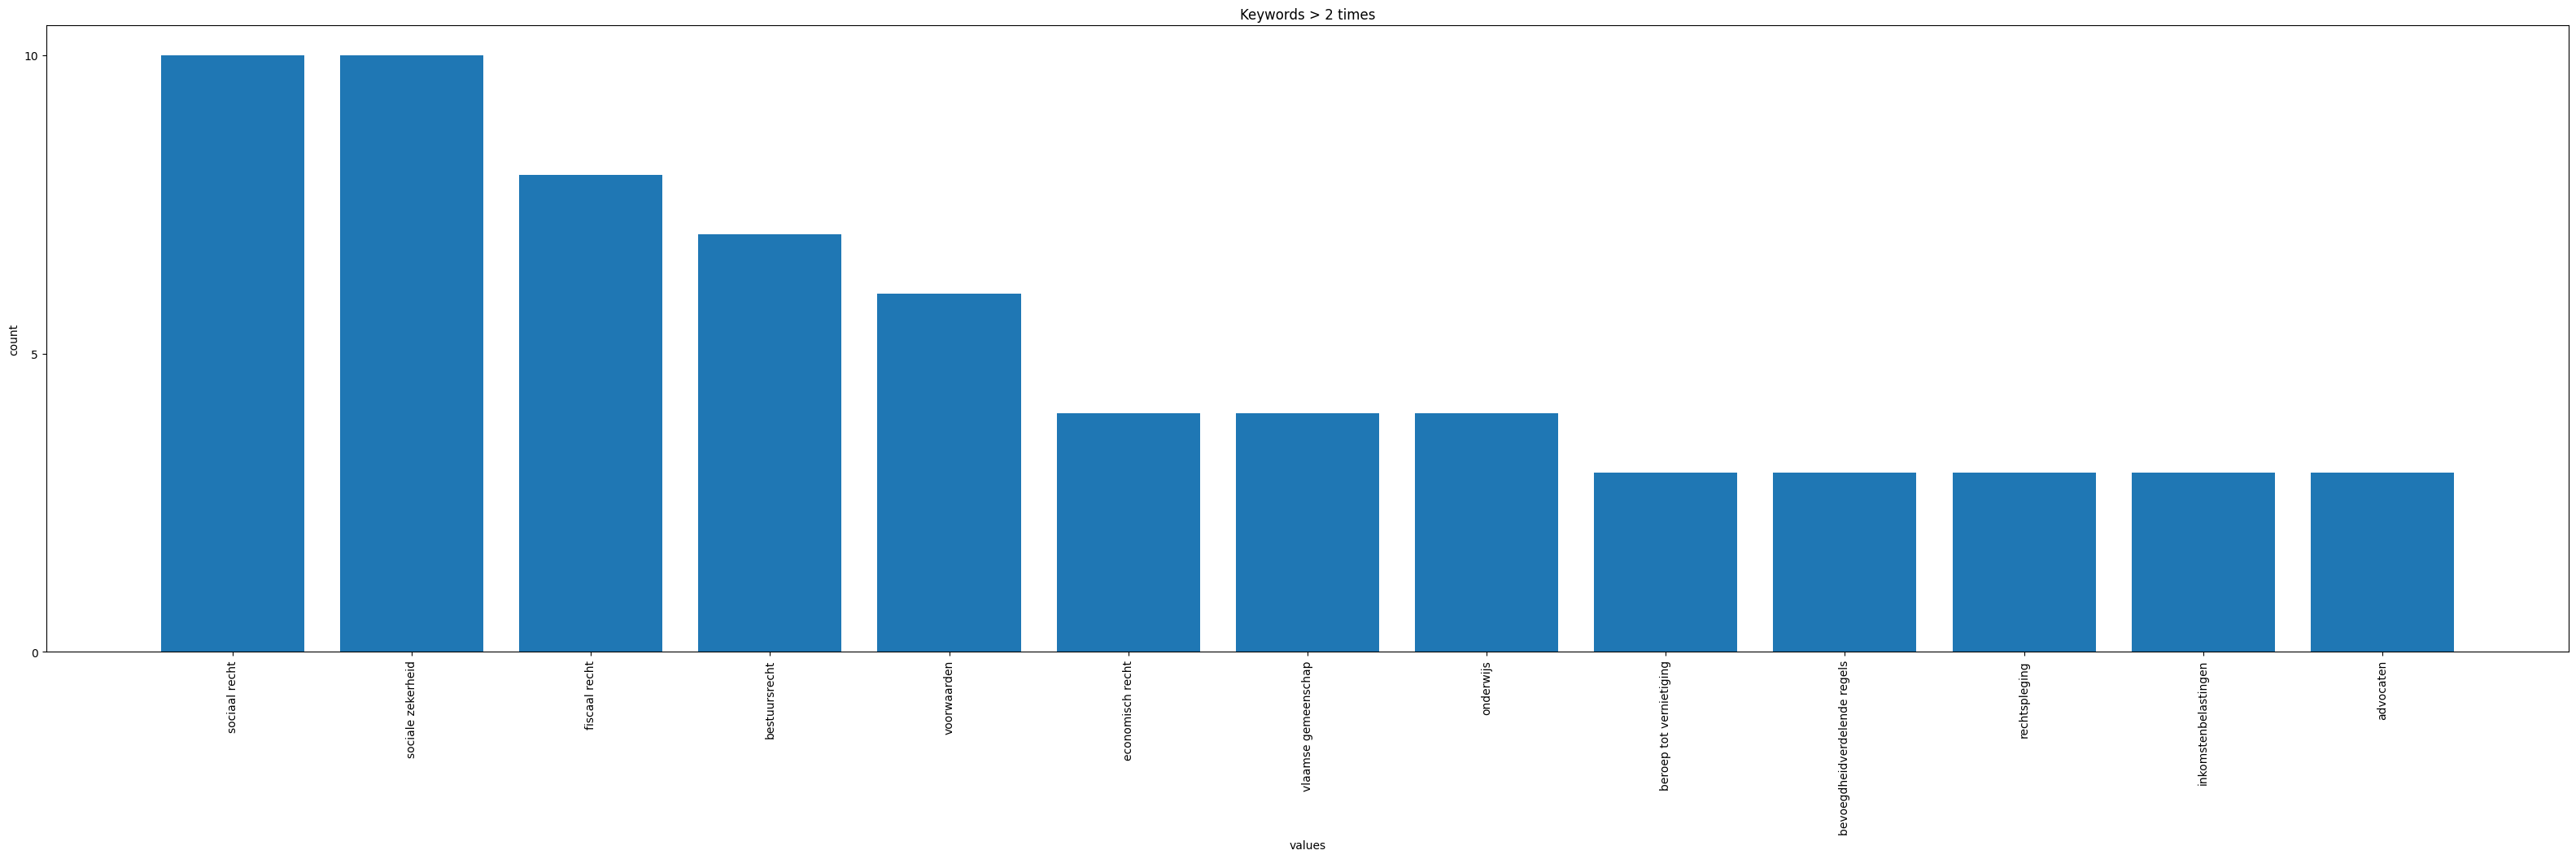

In [26]:
keywords_frequent = frequent(keywords_flat, 2) # create frequent_item for values > 2 
plot_frequent(keywords_frequent, title = "Keywords > 2 times") # plot actual graph

### Detailled assessment of frequency of keywords 

Below we assess for each case how many of its keywords are keywords that occur often (e.g. more than 9 times, 8 times ...). If for many cases those frequent keywords are the bulk of the keywords, than it might suffice to limit the analysis to those keywords. Then we can - for now - neglect the less frequent keywords.

In [29]:
# Determine threshold to see keyword as frequent, starting from 10 occurences
for minimum_count in range(10,0,-1):
    # Obtain keywords occuring more than minimum_count
    keywords_frequent = frequent(keywords_flat, minimum_count)
    
    # Create new list, only containing keywords, based on nested list created through ´frequent()´
    keywords_top = [keyword_count_pair[0] for keyword_count_pair in keywords_frequent]
    
    # Obtain for each case the ratio of keywords that are frequent as compared to all keywords for that case.
    ratios_keywords_top = [] # initialize empty list to store ratios
    # Iterate over cases
    for keywords_per_case_list in keywords_list:
        # Clean keywords_per_case_list
        keywords_per_case_list = keywords_clean(keywords_per_case_list)

        # Count how many keywords of that case also occur in keywords_top
        keyword_in_keywords_top_int = sum(1 for keyword in keywords_per_case_list if (keyword in keywords_top))

        # Obtain ratio of frequent keywords in total amount of keywords for this case
        ratio = keyword_in_keywords_top_int / len(keywords_per_case_list)
        ratios_keywords_top.append(round(ratio, 2)) # append ratio, rounded to 2 decimals 
    
    # assess for how many cases more than half of its keywords are in keywords_top
    more_than_half = sum(1 for ratio in ratios_keywords_top if (ratio > 0.5))
    
    print("For {0} cases, more than 50% of its keywords are keyword that occur more than {1} time(s), so {2:2.2%} of the cases.".
          format(more_than_half, 
                 minimum_count,
                 more_than_half / len(keywords_list)
                )
         ) 
    print("The ratio's for the first 50 cases are:", ratios_keywords_top[:50])
    print(50*"-")

0 keywords out of 299 unique values occur more than 10 times.
They represent 0 of the total amount of values (i.e. 377), so 0.00%.
For 0 cases, more than 50% of its keywords are keyword that occur more than 10 time(s), so 0.00% of the cases.
The ratio's for the first 50 cases are: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
--------------------------------------------------
2 keywords out of 299 unique values occur more than 9 times.
They represent 20 of the total amount of values (i.e. 377), so 5.31%.
For 0 cases, more than 50% of its keywords are keyword that occur more than 9 time(s), so 0.00% of the cases.
The ratio's for the first 50 cases are: [0.0, 0.0, 0.0, 0.22, 0.2, 0.25, 0.0, 0.22, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.29, 0.29, 0.0, 0.0, 0.29, 0.0, 0.0, 0.0, 0.0, 0.0

Many cases contain a substantial amount of niche keywords, that only occur limitedly in the dataset. Hence, an approach to discard uncommon keywords and focus on the common keywords seems undesirable. 

In [28]:
frequent(keywords_flat, 2)

13 keywords out of 299 unique values occur more than 2 times.
They represent 68 of the total amount of values (i.e. 377), so 18.04%.


[['sociaal recht', 10],
 ['sociale zekerheid', 10],
 ['fiscaal recht', 8],
 ['bestuursrecht', 7],
 ['voorwaarden', 6],
 ['economisch recht', 4],
 ['vlaamse gemeenschap', 4],
 ['onderwijs', 4],
 ['beroep tot vernietiging', 3],
 ['bevoegdheidverdelende regels', 3],
 ['rechtspleging', 3],
 ['inkomstenbelastingen', 3],
 ['advocaten', 3]]

# Type procedure

Subsequently we extract all types of procedures and explore those.

In [27]:
# extract all types of procedures
type_procedures_list = data["type procedure"].tolist() # apply ".to_list()" or output is Series

# inspect results
type_procedures_list[:20]

['Beroep tot vernietiging',
 'Prejudiciële vraag',
 'Beroep tot vernietiging',
 'Beroep tot vernietiging',
 'Prejudiciële vragen',
 'Prejudiciële vragen',
 'Prejudiciële vraag',
 'Prejudiciële vragen',
 'Beroepen tot vernietiging',
 'Prejudiciële vragen',
 'Beroep tot vernietiging',
 'Beroep tot vernietiging',
 'Prejudiciële vraag',
 'Beroep tot vernietiging',
 'Prejudiciële vragen',
 'Beroep tot vernietiging',
 'Beroep tot vernietiging',
 'Beroep tot vernietiging',
 'Prejudiciële vragen',
 'Prejudiciële vraag']

In [30]:
# Assess counts for all procedures
types_of_procedures_frequency_all = frequent(type_procedures_list) 
types_of_procedures_frequency_all

for minimum in range(1,1000,100):
    type_procedure_frequent = frequent(type_procedures_list, minimum)
    print(50*"-")

5 keywords out of 5 unique values occur more than 0 times.
They represent 61 of the total amount of values (i.e. 61), so 100.00%.


[['Prejudiciële vraag', 22],
 ['Beroep tot vernietiging', 20],
 ['Prejudiciële vragen', 11],
 ['Beroepen tot vernietiging', 7],
 ['Vordering tot schorsing', 1]]

4 keywords out of 5 unique values occur more than 1 times.
They represent 60 of the total amount of values (i.e. 61), so 98.36%.
--------------------------------------------------
0 keywords out of 5 unique values occur more than 101 times.
They represent 0 of the total amount of values (i.e. 61), so 0.00%.
--------------------------------------------------
0 keywords out of 5 unique values occur more than 201 times.
They represent 0 of the total amount of values (i.e. 61), so 0.00%.
--------------------------------------------------
0 keywords out of 5 unique values occur more than 301 times.
They represent 0 of the total amount of values (i.e. 61), so 0.00%.
--------------------------------------------------
0 keywords out of 5 unique values occur more than 401 times.
They represent 0 of the total amount of values (i.e. 61), so 0.00%.
--------------------------------------------------
0 keywords out of 5 unique values occur more than 501 times.
They represent 0 of the total amount of

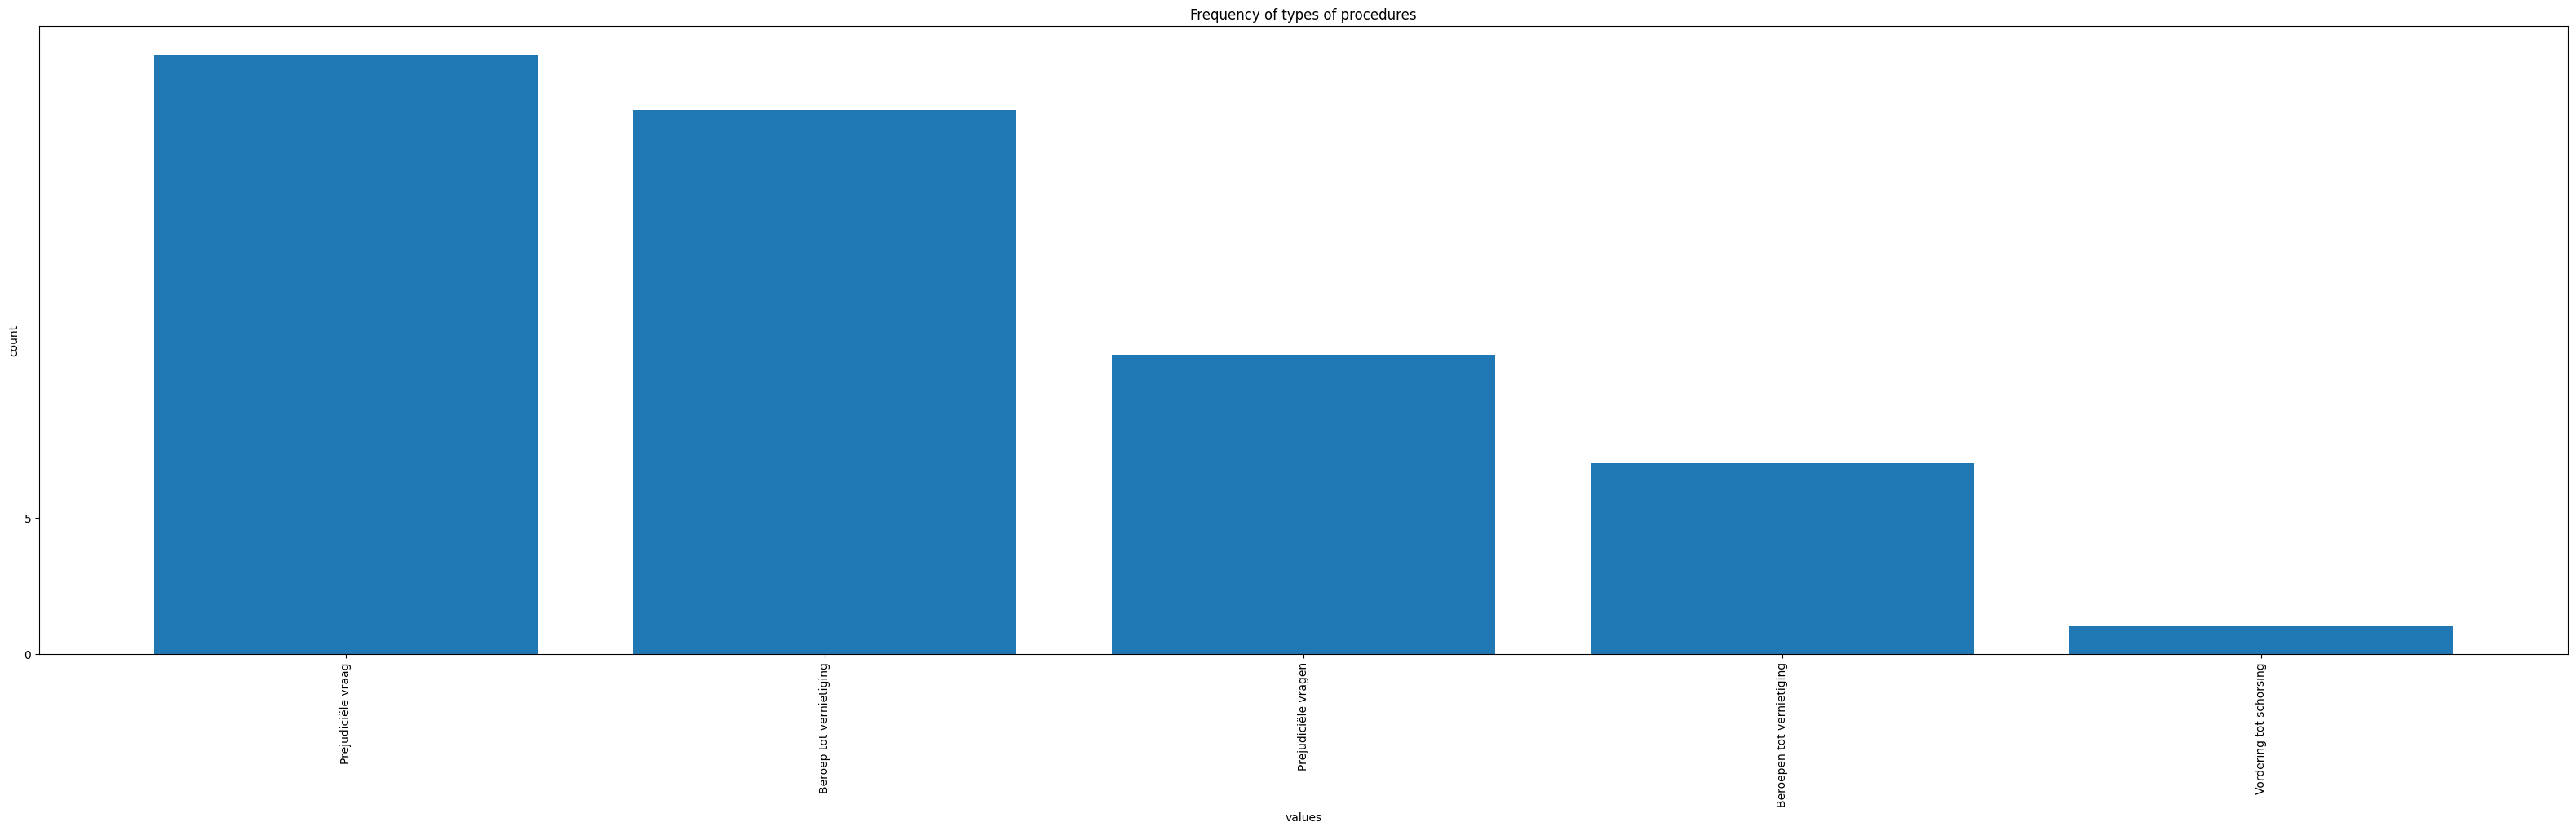

In [33]:
plot_frequent(types_of_procedures_frequency_all, title = "Frequency of types of procedures", 
              export = True, filename = "CC_most_frequent_procedures.png")

# Temporary chunks

### Length of keywords

Furthermore, many keywords appear rather descriptive, i.e. they summarize (part of) the case through a keyword in the form of a sentence with multiple words. To assess this we extract all keywords.

In [ ]:
# extract keywords out of 'all', leaving counts
keywords = [i[0] for i in all] 
len(keywords)
keywords[:5]

Many keywords actually contain quite a lot of words. To assess this, we obtain the amount of words with in each 'keyword', i.e. the length of the keyword and plot it againts the amount of keywords with such length.  

In [ ]:
# Assess lengths of keywords
keyword_length_all = [] # create variable to store length of each keyword 
for keyword in keywords:
    amount_words = keyword.split() # split keyword string into seperate words (i.e. split at spaces)
#     print(amount_words, "----", len(amount_words))
    keyword_length_all.append(len(amount_words)) # add length of list of words of each keyword

In [ ]:
# Assess which and how many different lenghts occur and store in keywords_lengths
keywords_lengths = list(set(keyword_length_all))

print(keywords_lengths)
len(keywords_lengths)

In [ ]:
# Count how many times each length of keywords occurs and store this.
# So then first count of occurences corresponds to count of the first registered length in keywords_lengths, etc.
occurences = [] 
for length in keywords_lengths:
    occurences.append(keyword_length_all.count(length))

print(occurences)
len(occurences)

We then create a dictionary that maps the keyword length with all keywords of that length. This way we can assess per length which keywords are present. This will help to assess whether it is possible to establish if keywords of a certain length are in essence summurazitions and not really keywords, or if they are still keywords but very verbose ones.

In [ ]:
# Creating dictionary containing all keywords of specific lengths (so with lengths as keys)
lenght_to_keyword_dict = {}
for length in keywords_lengths:
    # For each length (as key), add all keywords as value for which their keyword_length as provided by keyword_length_all at the same index as 'keyword' matches 'length'
    lenght_to_keyword_dict[length] = [keyword for index, keyword in enumerate(keywords) if keyword_length_all[index] == length]

# Assess dictionary
lenght_to_keyword_dict.keys()
# lenght_to_keyword_dict[7]

In [ ]:
lenght_to_keyword_dict

Visually, this resuls in the following graph.

In [ ]:
# keywords_lengths

In [ ]:
# function to add value labels to graph (see https://www.geeksforgeeks.org/adding-value-labels-on-a-matplotlib-bar-chart/)
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')

# change width and height of figure
f = plt.figure()
f.set_figwidth(40)
f.set_figheight(10)

# plt.xticks([]) # disabling xticks by Setting xticks to an empty list  (because too clotted)
# plt.xticks(keywords_lengths)
plt.xlabel(keywords_lengths)
# plt.xticks(labels = keywords_lengths, ticks = [i for i in range(len(keywords_lengths))]) # See https://www.geeksforgeeks.org/python-create-list-of-numbers-with-given-range/
# plt.xticks(rotation = 90) # rotate labels of keywords
plt.xticks(range(keywords_lengths[0], keywords_lengths[-1]+1, 1))#set the tick frequency on x-axis, ranging from first count to final count
plt.xlabel("Amount of words within keyword") #set the label for y axis
plt.ylabel("Occurence counts") #set the label for x-axis
plt.title("How many words do 'keywords' contain?") #set the title of the graph

addlabels(keywords_lengths, occurences) # add value labels

plt.bar(keywords_lengths, occurences) # Plot keywords_lenghts vs. occurences
plt.show()
f.savefig('../../graphs/2006_length_keywords.png')

## Exporting keywords

Write all keywords to file, together with their counts.

In [ ]:
# with open ("2006_all_keywords_counts.txt", "w", encoding="utf8" ) as output_file:
#     for keyword in all:
#         output_file.write("{0}\t{1}\n".format(keyword[1], keyword[0]))

We also extract only the keywords (so without the counts) and write all keywords to file.

In [ ]:
for keyword in all[:5]:
    print(keyword)

In [ ]:
# # Write keywords to file
# filename_output = "2006_all_keywords.txt"
# with open (data_location + "/" + filename_output, "w", encoding="utf8" ) as output_file:
#     for keyword in all:
#         output_file.write("{0}\n".format(keyword[0]))

# Test chunks

### Importing data

In [ ]:
# # Define data types for each column
# data_types_dict = {
#     'case number': str,
#     'role number': list,
#     'date': str,
#     'type procedure': str,
#     'controlled norm': str,
#     'outcome': str,
#     'keywords': list,
#     'url': str
#           }

In [ ]:
# type(data["role number"][0])

In [ ]:
# from ast import literal_eval
# data["keywords"] = data["keywords"].applymap(literal_eval)

In [ ]:
# keywords_list = data["keywords"][0]
# type(keywords_list)

In [ ]:
# len(keywords_list[0])
# keywords_list[0]

In [ ]:
# keywords_list

In [ ]:
# import json
# keywords_list_test = json.dumps(keywords_list_test_temp)
# keywords_list_test

### Frequency of keywords

In [ ]:
# #Define function to split keywords of each case
# def keywords_split(keywords_list: list):
#     keywords_sep = []
#     for keywords_per_entry in keywords_list:
#         keywords_sep.extend([i.strip() for i in keywords_per_entry]) # strip every keywords of spaces 
#     keywords_sep = [i.lower() for i in keywords_sep if i != ""] # remove left over empty characters + return lower case  
#     keywords_sep = [re.sub(r"1\.|2\.|\.", "", i) for i in keywords_sep ] # remove "1.", "2." and "." (with "." always escaped)   
#     keywords_sep = [i.replace("  ", " ").strip(" ") for i in keywords_sep] # remove double spaces in keywords
    
    
#     return keywords_sep

# # Perform splitting and stripping to keywords_list
# keywords_sep = keywords_split(keywords_list)

In [ ]:
# unique = list(set(keywords_sep))
# len(unique)

In [ ]:
# len(keywords_sep) # 31323

# keywords_counter = Counter(keywords_sep)
# len(keywords_counter) # 12971
# keywords_counter.most_common()[:100] 

In [ ]:
# # Extract all keywords together with their counts for further handling
# all = []
# for keyword, count in keywords_counter.items():
#     all.append([keyword, count])

# # sort keywords 
# all = sorted(all)  
# # len(all)
# all[:5]

In [ ]:
# type(keywords_counter)
# keywords_frequent == frequent

In [ ]:
# frequent = []
# for keyword, count in keywords_counter.items():
#     if count > 2:
#         frequent.append([keyword, count])

# # sort keywords based on how much they occur (high to low)
# frequent = sorted(frequent, key = lambda x: x[1], reverse = True)
        
# len(frequent)
# frequent

In [ ]:

# labels = [frequent[i][0] for i in range(len(frequent))] # extract labels from 'frequent'
# count = [frequent[i][1] for i in range(len(frequent))] # extract corresponding counts from 'frequent'

# # change width and height of figure
# f = plt.figure()
# f.set_figwidth(40)
# f.set_figheight(10)

# # plt.xticks([]) # disabling xticks by Setting xticks to an empty list  (because to clotted)
# # plt.xticks(labels = None) # hide labels 
# plt.xticks(rotation = 90) # rotate labels of keywords
# plt.yticks(range(0,len(labels)+1, 5))#set the tick frequency on x-axis
# plt.xlabel("keywords") #set the label for y axis
# plt.ylabel("count") #set the label for x-axis
# plt.title("Frequency of keywords") #set the title of the graph

# plt.bar(labels, count)
# plt.show()
# f.savefig('../../graphs/CC_most_frequent_keywords.png')

### Detailed assessment of frequency keywords

In [ ]:
# test_list = ['voorwaarden', 'test', 'ziekte- en invaliditeitsverzekering']
# keyword_in_keywords_top = sum(1 for keyword in test_list if (keyword in keywords_top))
# ratio = keyword_in_keywords_top / len(test_list)
# round(ratio, 2)

In [ ]:
#     keyword_in_keywords_top = 0 # set counter to 0 at each new case
    # Iterate over all the keywords for that case
#     for keyword in keywords_per_case_list:
        # If keyword in case is one of top keywords: increase count 
#         if (keyword in keywords_top): 
#             keyword_in_keywords_top = keyword_in_keywords_top + 1

In [ ]:
# ratios_keywords_top = [] # initialize empty list to store ratios

# # Iterate over cases
# for keywords_per_case_list in keywords_list[:10]:
#     print(keywords_per_case_list)
#     # Count how many keywords of that case also occur in keywords_top
#     keyword_in_keywords_top_int = sum(1 for keyword in keywords_per_case_list if (keyword in keywords_top))
  
#     # Obtain ratio of frequent keywords in total amount of keywords for this case
#     ratio = keyword_in_keywords_top_int / len(keywords_per_case_list)
#     ratios_keywords_top.append(round(ratio, 2)) # append ratio, rounded to 2 decimals   

In [ ]:
# for index, i in enumerate(ratios_keywords_top[:1000]):
#     print (index, i)
# # keywords_top

In [ ]:
# # ratios_keywords_top.index(1.0, 2)
# keywords_list[2]
# # np.where(ratios_keywords_top == 1.0)

In [69]:
# # Obtain keywords occuring > 9 times
# keywords_frequent = frequent(keywords_flat, 3)

# # # Inspect results
# # keywords_frequent

In [70]:
# # Create new list, only containing keywords, based on nested list created through ´frequent()´
# keywords_top = [keyword_count_pair[0] for keyword_count_pair in keywords_frequent]

# # Inspect results
# len(keywords_top)
# type(keywords_top)
# # keywords_top

Then we obtain for each case the ratio of keywords that are frequent as compared to all keywords for that case.

In [71]:
# ratios_keywords_top = [] # initialize empty list to store ratios

# # Iterate over cases
# for keywords_per_case_list in keywords_list:
#     # Clean keywords_per_case_list
#     keywords_per_case_list = keywords_clean(keywords_per_case_list)
    
#     # Count how many keywords of that case also occur in keywords_top
#     keyword_in_keywords_top_int = sum(1 for keyword in keywords_per_case_list if (keyword in keywords_top))
  
#     # Obtain ratio of frequent keywords in total amount of keywords for this case
#     ratio = keyword_in_keywords_top_int / len(keywords_per_case_list)
#     ratios_keywords_top.append(round(ratio, 2)) # append ratio, rounded to 2 decimals   

In [72]:
# # Assess result
# print(ratios_keywords_top[:50])

In [73]:
# sum(1 for ratio in ratios_keywords_top if (ratio > 0.5))

### Frequency of types of procedures

In [ ]:
# types_procedures_counter = Counter(type_procedures_list)
# len(types_procedures_counter) # 27
# types_procedures_counter.most_common()

In [ ]:
# types_procedures_counter

In [ ]:
# frequent = []
# for type_procedures, count in types_procedures_counter.items():
#     frequent.append([type_procedures, count])

# # sort keywords based on how much they occur (high to low)
# frequent = sorted(frequent, key = lambda x: x[1], reverse = True)
        
# len(frequent)
# frequent

Plot those types of procedures.

In [ ]:
# labels = [frequent[i][0] for i in range(len(frequent))] # extract labels from 'frequent'
# count = [frequent[i][1] for i in range(len(frequent))] # extract corresponding counts from 'frequent'

# # change width and height of figure
# f = plt.figure()
# f.set_figwidth(40)
# f.set_figheight(10)

# # plt.xticks([]) # disabling xticks by Setting xticks to an empty list  (because to clotted)
# # plt.xticks(labels = None) # hide labels 
# plt.xticks(rotation = 90) # rotate labels of keywords
# plt.yticks(range(0,len(labels)+1, 5))#set the tick frequency on x-axis
# plt.xlabel("Type of procedure") #set the label for y axis
# plt.ylabel("count") #set the label for x-axis
# plt.title("Frequency of type of procedure") #set the title of the graph

# plt.bar(labels, count)
# plt.show()
# f.savefig('../../graphs/CC_most_frequent_procedues.png')